In [56]:
import pandas as pd
import seaborn as sns
import numpy as np

In [57]:
import os, sys
import eh_translator as t

idx = t._load_or_build_indexes()
print('hun_to_eng size ->', len(idx['hun_to_eng']))
print('eng_to_hun size ->', len(idx['eng_to_hun']))

hun_to_eng size -> 139935
eng_to_hun size -> 90262


In [58]:
# Select how many chunks are present in the dataset (2..5)
type = 3  # set between 2 and 5
assert 2 <= type <= 5, 'type must be between 2 and 5'

# Derive column name lists based on the selected type
chunk_cols = [f'chunk{i}' for i in range(1, type + 1)]
logfreq_cols = [f'logfreq_chunk{i}' for i in range(1, type + 1)]
length_cols = [f'length_chunk{i}' for i in range(1, type + 1)]
euclid_corpus_cols = [f'euclidean_corpus_and_chunk{i}' for i in range(1, type + 1)]
from itertools import combinations
euclid_pair_cols = [f'euclidean_distance_chunk{i}_and_chunk{j}' for i, j in combinations(range(1, type + 1), 2)]


In [59]:
all_hun = pd.Series(idx['hun_to_eng'].keys())

In [60]:
all_hun = all_hun.str.replace('-', '')
all_hun = all_hun.drop_duplicates()


In [61]:
#all_hun_basic = ['a','á','b','c','d','e','é','f','g','h','i','í','j','k','l','m','n','o','ó','ö','ő','p','q','r','s','t','u','ú','ü','ű','v','w','x','y','z']



In [62]:
# Load the right file based on the selected type (2..5)
df = pd.read_csv(f'word_combinations/words_with_distances_{type}.csv')

# Adjust low-frequency for non-Hungarian short tokens across corpus+chunks
for word_column in chunk_cols + ['corpus']:
    logfreq_column = f'logfreq_{word_column}'
    lenght_colum = f'length_{word_column}'

    df[logfreq_column] = np.where(
        (~df[word_column].isin(all_hun)) & (df[lenght_colum] < 4), 
        1, df[logfreq_column] 
    )


In [63]:
df['logfreq_chunk1'].astype(int).value_counts()

logfreq_chunk1
3    641
4    542
2    249
5    112
6     71
7     50
Name: count, dtype: int64

In [69]:
df.head()

,count_of_chunks,corpus,chunk1,chunk2,chunk3,euclidean_distance_chunk1_and_chunk2,euclidean_distance_chunk1_and_chunk3,euclidean_distance_chunk2_and_chunk3,euclidean_corpus_and_chunk1,euclidean_corpus_and_chunk2,euclidean_corpus_and_chunk3,euclidean_corpus_and_all_chunks,length_corpus,length_chunk1,length_chunk2,length_chunk3,logfreq_corpus,logfreq_chunk1,logfreq_chunk2,logfreq_chunk3
0,3,amikor,a,mi,kor,11.477338,11.341975,13.159287,15.723590,15.501154,16.256109,13.565187,6,1,2,3,5.467017,7.140229,6.162454,3.407731
1,3,akarok,a,kar,ok,10.942738,10.499693,10.484509,15.339861,13.033290,14.966578,11.734228,6,1,3,2,5.164555,7.140229,3.290925,4.570555
2,3,istenem,is,te,nem,10.594688,9.926642,9.824814,15.578640,15.443579,15.137317,10.657391,7,2,2,3,5.070115,6.274002,5.976475,6.820146
3,3,érdekel,ér,de,kel,12.920251,9.674317,12.417307,20.885342,23.301779,20.589685,8.232261,7,2,2,3,4.800882,4.434840,6.256957,3.475671
4,3,egyáltalán,egy,ál,talán,14.519530,19.354733,17.728544,25.708481,27.770439,17.274179,9.850601,10,3,2,5,4.761146,6.513669,2.622214,5.513448


In [64]:
# Build dynamic filtering across all chunks based on selected type
conds = []
# Each chunk must have (logfreq + length > 6) and logfreq < 7
for i in range(1, type + 1):
    conds.append((df[f'logfreq_chunk{i}'] + df[f'length_chunk{i}'] > 6))
    conds.append((df[f'logfreq_chunk{i}'] < 7))
# Corpus length constraint
conds.append(df['length_corpus'] > 7)
# Pairwise chunk length sums > 2 for all pairs
from itertools import combinations
for i, j in combinations(range(1, type + 1), 2):
    conds.append((df[f'length_chunk{i}'] + df[f'length_chunk{j}'] > 2))

import functools, operator
mask = functools.reduce(operator.and_, conds) if conds else True
df_filtered = df[mask].copy()
print(len(df_filtered))
df_filtered.head(1)

739


,count_of_chunks,corpus,chunk1,chunk2,chunk3,euclidean_distance_chunk1_and_chunk2,euclidean_distance_chunk1_and_chunk3,euclidean_distance_chunk2_and_chunk3,euclidean_corpus_and_chunk1,euclidean_corpus_and_chunk2,euclidean_corpus_and_chunk3,euclidean_corpus_and_all_chunks,length_corpus,length_chunk1,length_chunk2,length_chunk3,logfreq_corpus,logfreq_chunk1,logfreq_chunk2,logfreq_chunk3
5,3,hamarosan,ha,mar,osan,11.813581,8.658793,10.966309,22.975607,21.266592,22.478287,9.299169,9,2,3,4,4.566756,6.178496,3.124504,2.630428


In [65]:
df.columns

Index(['count_of_chunks', 'corpus', 'chunk1', 'chunk2', 'chunk3',
       'euclidean_distance_chunk1_and_chunk2',
       'euclidean_distance_chunk1_and_chunk3',
       'euclidean_distance_chunk2_and_chunk3', 'euclidean_corpus_and_chunk1',
       'euclidean_corpus_and_chunk2', 'euclidean_corpus_and_chunk3',
       'euclidean_corpus_and_all_chunks', 'length_corpus', 'length_chunk1',
       'length_chunk2', 'length_chunk3', 'logfreq_corpus', 'logfreq_chunk1',
       'logfreq_chunk2', 'logfreq_chunk3'],
      dtype='object')

<Axes: >

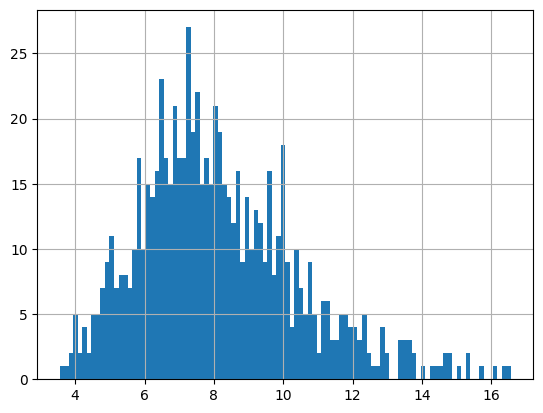

In [66]:
 df_filtered['euclidean_corpus_and_all_chunks'].hist(bins=100)

In [ ]:
# Dynamic sums based on selected type (2..5)
dist_sum = df_filtered[euclid_corpus_cols].sum(axis=1)
df_filtered['sum_logfreq'] = df_filtered[logfreq_cols].sum(axis=1)

# Sum all pairwise chunk distances
dist_pair_sum = df_filtered[euclid_pair_cols].sum(axis=1)

# Subtract sqrt of pairwise sum from sum_distance
df_filtered['sum_distance'] = df_filtered['euclidean_corpus_and_all_chunks'] + dist_sum - np.sqrt(dist_pair_sum)


In [68]:
df_filtered.sort_values(by='sum_distance', ascending=False).iloc[100:150] # sort_values(by='sum_logfreq', ascending=False).head(1000)

,count_of_chunks,corpus,chunk1,chunk2,chunk3,euclidean_distance_chunk1_and_chunk2,euclidean_distance_chunk1_and_chunk3,euclidean_distance_chunk2_and_chunk3,euclidean_corpus_and_chunk1,euclidean_corpus_and_chunk2,...,length_corpus,length_chunk1,length_chunk2,length_chunk3,logfreq_corpus,logfreq_chunk1,logfreq_chunk2,logfreq_chunk3,sum_logfreq,sum_distance
1118,3,készteti,kész,te,ti,15.617782,16.461050,8.603772,15.363426,27.023804,...,8,4,2,2,2.540329,4.790419,5.976475,4.868462,15.635356,37.894918
420,3,juthatott,jut,hat,ott,11.815134,10.056892,9.398901,20.378210,20.242264,...,9,3,3,3,2.972666,4.273649,4.542788,5.565866,14.382303,37.770935
1085,3,hadihajó,hadi,ha,jó,15.900164,17.350367,8.152987,14.738506,27.262142,...,8,4,2,2,2.555094,2.781037,6.178496,5.916272,14.875805,37.743925
1316,3,állhatott,áll,hat,ott,12.178682,10.811336,9.398901,21.421623,21.156984,...,9,3,3,3,2.457882,4.910149,4.542788,5.565866,15.018803,37.714382
142,3,magadhoz,mag,ad,hoz,11.848570,12.256816,9.872430,20.497713,20.668905,...,8,3,2,3,3.471292,3.175512,4.265996,4.024773,11.466281,37.663203
55,3,mondhatok,mond,hat,ok,10.707591,10.809038,12.136322,21.612030,20.288155,...,9,4,3,2,3.782974,4.603274,4.542788,4.570555,13.716617,37.609078
94,3,négyszemközt,négy,szem,közt,13.677813,13.669753,11.490343,23.054850,21.107239,...,12,4,4,4,3.616265,4.631231,3.861295,4.160679,12.653205,37.467206
158,3,rendezte,rend,ez,te,12.260999,11.397848,10.779348,19.453672,21.758780,...,8,4,2,2,3.410609,3.426023,6.333684,5.976475,15.736182,37.446531
1047,3,békefenntartó,béke,fenn,tartó,12.480487,15.289346,14.655725,23.312128,23.675724,...,13,4,4,5,2.570543,3.796505,3.868409,3.593064,11.257979,37.406941
361,3,magadért,mag,ad,ért,11.848570,12.870447,11.312388,20.622396,20.578169,...,8,3,2,3,3.046885,3.175512,4.265996,4.410440,11.851948,37.220714


In [31]:
df_filtered[df_filtered.corpus == 'közösülés']

,count_of_chunks,corpus,chunk1,chunk2,euclidean_distance_chunk1_and_chunk2,euclidean_corpus_and_chunk1,euclidean_corpus_and_chunk2,euclidean_corpus_and_all_chunks,length_corpus,length_chunk1,length_chunk2,logfreq_corpus,logfreq_chunk1,logfreq_chunk2,sum_logfreq,sum_distance
4835,2,közösülés,közös,ülés,13.877374,8.735933,19.898245,8.372046,9,5,4,2.586587,4.276048,3.258637,7.534685,23.12885


In [51]:
df_filtered[df.corpus == 'házassaga']

/var/folders/59/v5dbhk2s3xx2rh5prvb8hs7r0000gn/T/ipykernel_71408/267378905.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered[df.corpus == 'házassaga']


,count_of_chunks,corpus,chunk1,chunk2,euclidean_distance_chunk1_and_chunk2,euclidean_corpus_and_chunk1,euclidean_corpus_and_chunk2,euclidean_corpus_and_all_chunks,length_corpus,length_chunk1,length_chunk2,logfreq_corpus,logfreq_chunk1,logfreq_chunk2,sum_logfreq,sum_distance
